# Notebook 2 — Compressed Sensing MRI: Wavelet-Regularized ISTA & FISTA

**Goal**: Solve the CS-MRI optimization problem using proximal gradient methods.

**Problem**: Minimize  `(1/2)||Ax - y||² + λ ||Ψx||₁`

where `A = M·F` (masked Fourier), `Ψ` = wavelet transform, `λ` = regularization weight.

**Algorithms**:
- **ISTA** (Iterative Shrinkage-Thresholding): gradient step + wavelet soft-threshold
- **FISTA** (Fast ISTA): adds Nesterov momentum for `O(1/k²)` convergence

**Key conventions**:
- Mask center band correctly placed at DC (index 0, wrapping) in unshifted FFT convention
- Orthonormal FFT (`norm="ortho"`) throughout
- Standard PSNR/SSIM metrics
- `db4` wavelet, level 4 (good sparsity for medical images)

In [263]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt

from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim

np.random.seed(0)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
})

In [264]:
image = shepp_logan_phantom()
image = resize(image, (256, 256), anti_aliasing=True).astype(np.float32)
N = image.shape[0]
print(f"Image shape: {image.shape}, range: [{image.min():.3f}, {image.max():.3f}]")

Image shape: (256, 256), range: [0.000, 1.000]


## Forward Model & Masks (Corrected Convention)

The mask lives in the **unshifted FFT domain** where DC is at index 0.
The center band wraps around index 0: columns `{0,...,c-1}` ∪ `{N-c,...,N-1}`.

In [265]:
# forward model (orthonormal FFT)
def A(x, mask):
    """Forward: y = M * F(x), norm='ortho'."""
    return mask * np.fft.fft2(x, norm="ortho")

def AT(y, mask):
    """Adjoint: x = F^H(M * y), norm='ortho'."""
    return np.fft.ifft2(mask * y, norm="ortho")


# mask gen
def make_cartesian_mask(N, R, center_frac=0.08):
    mask = np.zeros((N, N), dtype=np.float32)
    mask[:, ::R] = 1.0
    c = max(1, int((center_frac * N) / 2))
    mask[:, :c] = 1.0
    mask[:, N - c:] = 1.0
    return mask

def random_cartesian_mask(N, accel=4, center_frac=0.08, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    mask = np.zeros((N, N), dtype=np.float32)
    c = max(1, int((center_frac * N) / 2))
    center_cols = np.concatenate([np.arange(0, c), np.arange(N - c, N)])
    num_cols = max(len(center_cols), N // accel)
    remaining = num_cols - len(center_cols)
    candidates = np.setdiff1d(np.arange(N), center_cols)
    if remaining > 0:
        pick = rng.choice(candidates, size=remaining, replace=False)
        cols = np.concatenate([center_cols, pick])
    else:
        cols = center_cols
    mask[:, cols] = 1.0
    return mask

def effective_acceleration(mask):
    return mask.shape[1] / np.sum(mask[0, :])

def compute_psnr(recon, truth, data_range=None):
    if data_range is None:
        data_range = float(truth.max() - truth.min())
    mse = np.mean((recon - truth) ** 2)
    if mse < 1e-15:
        return float("inf")
    return 20.0 * np.log10(data_range / np.sqrt(mse))

def compute_ssim(recon, truth, data_range=None):
    if data_range is None:
        data_range = float(truth.max() - truth.min())
    return ssim(recon, truth, data_range=data_range)

def compute_nmse(recon, truth):
    return float(np.sum((recon - truth) ** 2) / (np.sum(truth ** 2) + 1e-12))

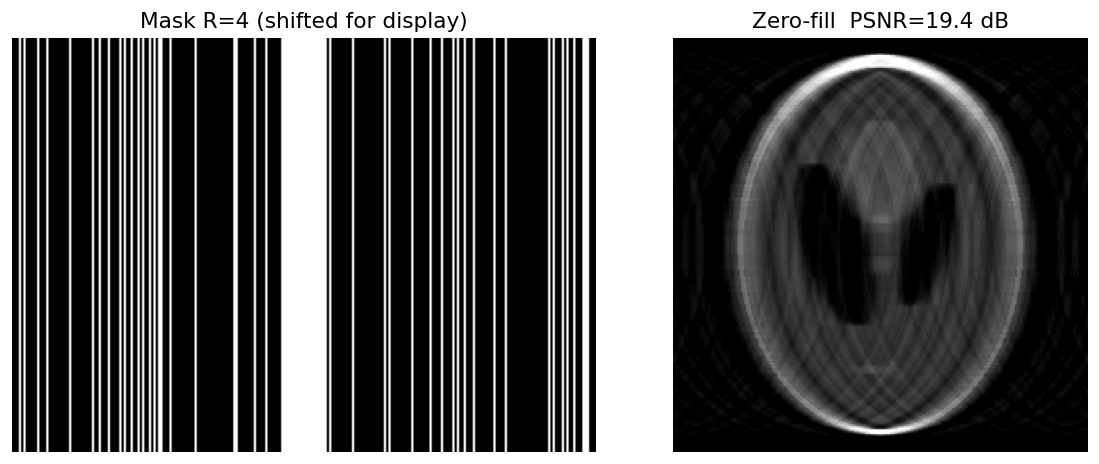

In [266]:
# verify mask + forward model
R_test = 4
rng = np.random.default_rng(7)
mask_test = random_cartesian_mask(N, accel=R_test, center_frac=0.08, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.fft.fftshift(mask_test), cmap="gray", aspect="auto")
axes[0].set_title(f"Mask R={R_test} (shifted for display)")
axes[0].axis("off")

y = A(image, mask_test)
zf = np.real(AT(y, mask_test))
axes[1].imshow(zf, cmap="gray", vmin=image.min(), vmax=image.max())
axes[1].set_title(f"Zero-fill  PSNR={compute_psnr(zf, image):.1f} dB")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Wavelet Proximal Operator

The proximal operator of `λ||Ψ·||₁` is wavelet soft-thresholding:
`prox_{λτ}(z) = Ψ^H · soft(Ψz, λτ)`

We use `db4` wavelets at level 4 with periodic boundary conditions.
The approximation coefficients (coarsest scale) are **not** thresholded
since they carry the bulk image contrast.

In [267]:
def wavelet_soft_thresh(x, threshold, wavelet="db4", level=4, mode="periodization"):
    """Wavelet-domain soft thresholding (proximal operator for l1-wavelet).

    Only detail coefficients are thresholded; approximation coefficients are kept.
    """
    coeffs = pywt.wavedec2(x, wavelet=wavelet, level=level, mode=mode)
    cA = coeffs[0]
    new_coeffs = [cA]
    for (cH, cV, cD) in coeffs[1:]:
        new_coeffs.append((
            pywt.threshold(cH, threshold, mode="soft"),
            pywt.threshold(cV, threshold, mode="soft"),
            pywt.threshold(cD, threshold, mode="soft"),
        ))
    rec = pywt.waverec2(new_coeffs, wavelet=wavelet, mode=mode)
    return rec[:x.shape[0], :x.shape[1]]

## ISTA Implementation

Each iteration:
1. **Gradient step**: `z = x - τ · ∇f(x)` where `∇f(x) = 2·A^H(Ax - y)`
2. **Proximal step**: `x_{k+1} = prox_{λτ}(z)` = wavelet soft-threshold

Step size `τ` must satisfy `τ < 1/L` where `L = 2||A||² = 2` (since `||A|| ≤ 1`
with ortho FFT and binary mask). So `τ < 0.5` guarantees convergence.

In [268]:
def ista_cs_mri(y, mask, image_gt, lam=0.01, step=0.2, iters=100,
               wavelet="db4", level=4, verbose=True):
    """ISTA for CS-MRI: min (1/2)||Ax-y||^2 + lam * ||Psi x||_1."""
    assert step < 0.5, f"Step size {step} >= 0.5; convergence not guaranteed"
    x = np.real(AT(y, mask)).astype(np.float32)

    history = {"psnr": [], "ssim": []}

    for k in range(iters):
        residual = A(x, mask) - y
        grad = 2.0 * np.real(AT(residual, mask))
        z = x - step * grad
        x = wavelet_soft_thresh(z, lam * step, wavelet=wavelet, level=level).astype(np.float32)

        p = compute_psnr(x, image_gt)
        s = compute_ssim(x, image_gt)
        history["psnr"].append(p)
        history["ssim"].append(s)

        if verbose and (k % 20 == 0 or k == iters - 1):
            print(f"  ISTA iter {k:3d} | PSNR={p:.2f} dB | SSIM={s:.4f}")

    return x, history

## FISTA: Adding Nesterov Momentum

FISTA accelerates ISTA from `O(1/k)` to `O(1/k²)` convergence rate.

In [269]:
def fista_cs_mri(y, mask, image_gt, lam=0.01, step=0.2, iters=100,
                wavelet="db4", level=4, verbose=True):
    """FISTA for CS-MRI with Nesterov momentum."""
    assert step < 0.5, f"Step size {step} >= 0.5; convergence not guaranteed"
    x = np.real(AT(y, mask)).astype(np.float32)
    z = x.copy()
    t = 1.0

    history = {"psnr": [], "ssim": []}

    for k in range(iters):
        residual = A(z, mask) - y
        grad = 2.0 * np.real(AT(residual, mask))
        x_new = z - step * grad
        x_new = wavelet_soft_thresh(x_new, lam * step, wavelet=wavelet, level=level).astype(np.float32)

        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        x, t = x_new, t_new

        p = compute_psnr(x, image_gt)
        s = compute_ssim(x, image_gt)
        history["psnr"].append(p)
        history["ssim"].append(s)

        if verbose and (k % 20 == 0 or k == iters - 1):
            print(f"  FISTA iter {k:3d} | PSNR={p:.2f} dB | SSIM={s:.4f}")

    return x, history

In [270]:
R = 4
center_frac = 0.08
rng = np.random.default_rng(42)
mask = random_cartesian_mask(N, accel=R, center_frac=center_frac, rng=rng)
y = A(image, mask)
zf = np.real(AT(y, mask))

print(f"=== Random mask R={R}, eff_R={effective_acceleration(mask):.1f} ===")
print(f"Zero-fill: PSNR={compute_psnr(zf, image):.2f}, SSIM={compute_ssim(zf, image):.4f}\n")

print("--- ISTA (lam=0.01, step=0.2, 100 iters) ---")
x_ista, h_ista = ista_cs_mri(y, mask, image, lam=0.01, step=0.2, iters=100)

print("\n--- FISTA (lam=0.01, step=0.2, 100 iters) ---")
x_fista, h_fista = fista_cs_mri(y, mask, image, lam=0.01, step=0.2, iters=100)

=== Random mask R=4, eff_R=4.0 ===
Zero-fill: PSNR=19.23, SSIM=0.3916

--- ISTA (lam=0.01, step=0.2, 100 iters) ---
  ISTA iter   0 | PSNR=19.37 dB | SSIM=0.3788
  ISTA iter  20 | PSNR=19.88 dB | SSIM=0.3291
  ISTA iter  40 | PSNR=20.06 dB | SSIM=0.3393
  ISTA iter  60 | PSNR=20.21 dB | SSIM=0.3484
  ISTA iter  80 | PSNR=20.32 dB | SSIM=0.3561
  ISTA iter  99 | PSNR=20.42 dB | SSIM=0.3624

--- FISTA (lam=0.01, step=0.2, 100 iters) ---
  FISTA iter   0 | PSNR=19.37 dB | SSIM=0.3788
  FISTA iter  20 | PSNR=20.27 dB | SSIM=0.3518
  FISTA iter  40 | PSNR=20.91 dB | SSIM=0.3933
  FISTA iter  60 | PSNR=21.35 dB | SSIM=0.4230
  FISTA iter  80 | PSNR=21.64 dB | SSIM=0.4411
  FISTA iter  99 | PSNR=21.78 dB | SSIM=0.4474


## Convergence Comparison

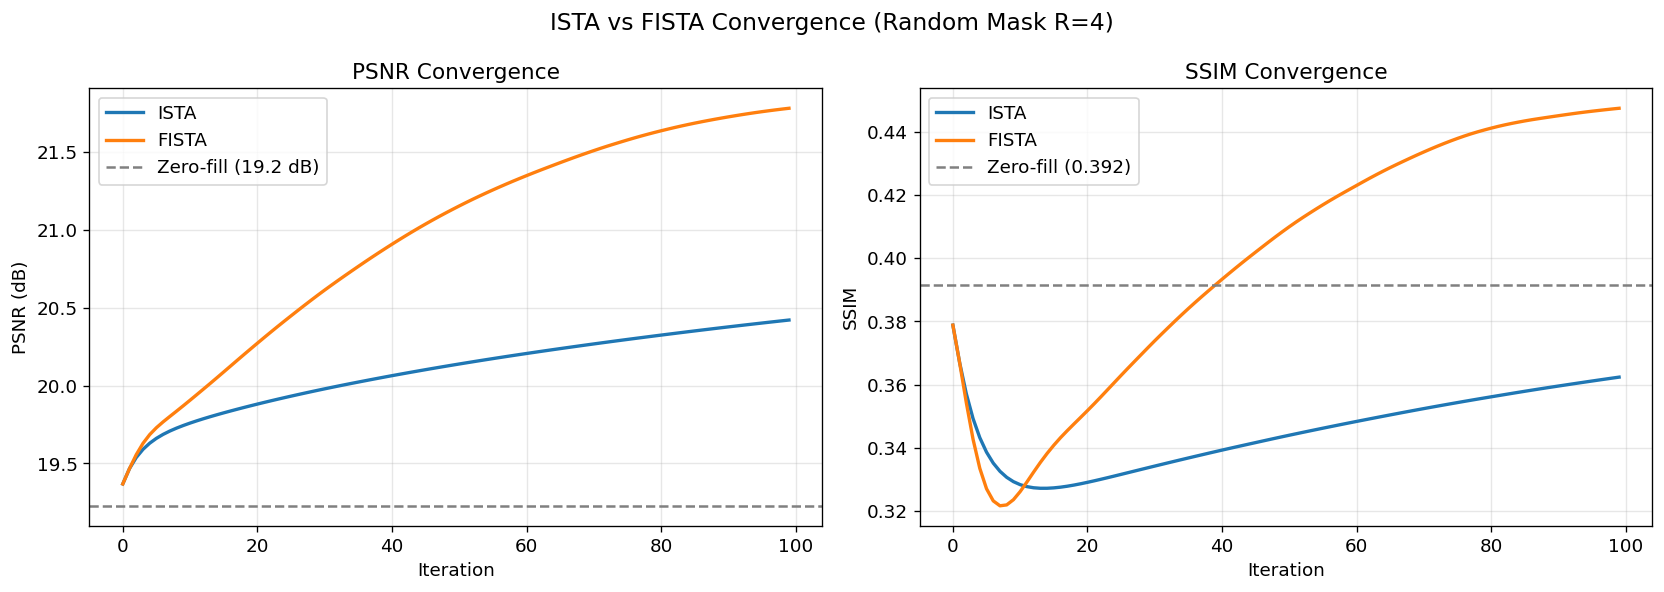

In [271]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h_ista["psnr"], label="ISTA", linewidth=2)
axes[0].plot(h_fista["psnr"], label="FISTA", linewidth=2)
zf_psnr = compute_psnr(zf, image)
axes[0].axhline(zf_psnr, color="gray", linestyle="--", label=f"Zero-fill ({zf_psnr:.1f} dB)")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR Convergence"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(h_ista["ssim"], label="ISTA", linewidth=2)
axes[1].plot(h_fista["ssim"], label="FISTA", linewidth=2)
zf_ssim = compute_ssim(zf, image)
axes[1].axhline(zf_ssim, color="gray", linestyle="--", label=f"Zero-fill ({zf_ssim:.3f})")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("SSIM")
axes[1].set_title("SSIM Convergence"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle(f"ISTA vs FISTA Convergence (Random Mask R={R})", fontsize=14)
plt.tight_layout()
plt.show()

## Hyperparameter Sweep

In [272]:
Rs = [2, 4, 8]
lam_grid = {
    2:  [0.002, 0.005, 0.01, 0.02, 0.04],
    4:  [0.001, 0.002, 0.005, 0.01, 0.02],
    8:  [0.0005, 0.001, 0.002, 0.005, 0.01],
}
results = []
best_recons = {}

for mask_type in ["cartesian", "random"]:
    for R in Rs:
        rng_sweep = np.random.default_rng(R * 100)
        if mask_type == "cartesian":
            mask_eval = make_cartesian_mask(N, R, center_frac=0.08)
        else:
            mask_eval = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng_sweep)

        y_eval = A(image, mask_eval)
        zf_eval = np.real(AT(y_eval, mask_eval))
        zf_p = compute_psnr(zf_eval, image)
        zf_s = compute_ssim(zf_eval, image)

        best_psnr, best_lam, best_x = -1e9, None, None
        for lam in lam_grid[R]:
            x_f, _ = fista_cs_mri(y_eval, mask_eval, image, lam=lam, step=0.3,
                                  iters=150, verbose=False)
            p = compute_psnr(x_f, image)
            if p > best_psnr:
                best_psnr, best_lam, best_x = p, lam, x_f

        best_s = compute_ssim(best_x, image)
        best_recons[(mask_type, R)] = (best_x, best_lam, best_psnr, best_s)
        print(f"{mask_type:9s} R={R} | ZF: {zf_p:.2f}/{zf_s:.3f} | "
              f"FISTA(lam={best_lam}): {best_psnr:.2f}/{best_s:.3f} | "
              f"delta={best_psnr - zf_p:+.2f} dB")

cartesian R=2 | ZF: 21.32/0.518 | FISTA(lam=0.005): 22.07/0.587 | delta=+0.74 dB
cartesian R=4 | ZF: 19.67/0.403 | FISTA(lam=0.005): 20.16/0.402 | delta=+0.50 dB
cartesian R=8 | ZF: 18.87/0.352 | FISTA(lam=0.001): 19.23/0.351 | delta=+0.35 dB
random    R=2 | ZF: 22.88/0.422 | FISTA(lam=0.002): 44.19/0.954 | delta=+21.31 dB
random    R=4 | ZF: 19.95/0.353 | FISTA(lam=0.005): 25.19/0.493 | delta=+5.24 dB
random    R=8 | ZF: 18.98/0.429 | FISTA(lam=0.001): 19.49/0.327 | delta=+0.51 dB


## Publication-Quality Comparison Figure

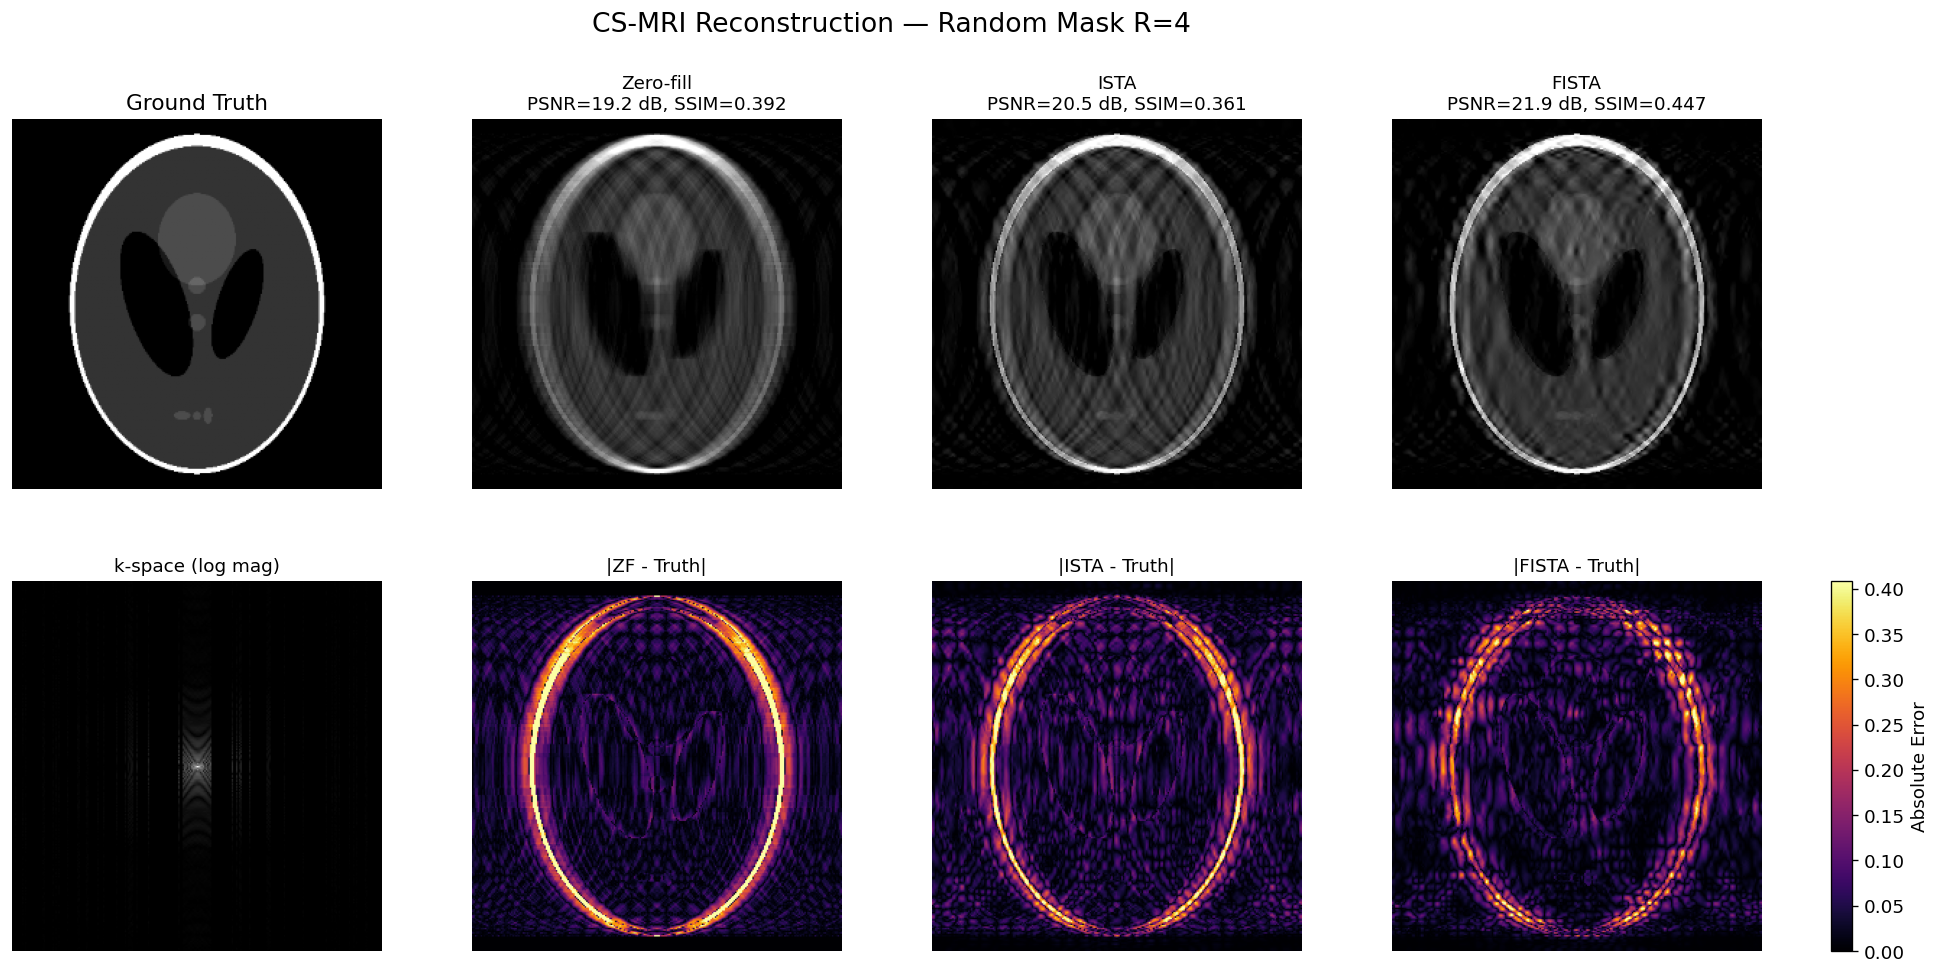

In [273]:
def paper_figure_nb2(truth, zf, ista, fista, y_kspace, title=""):
    """2-row figure: reconstructions (top) + error maps (bottom).
    Uses GridSpec with a dedicated colorbar column to avoid overlap."""
    vmin, vmax = float(truth.min()), float(truth.max())

    ezf = np.abs(zf - truth)
    eista = np.abs(ista - truth)
    efista = np.abs(fista - truth)
    emax = float(np.quantile(np.stack([ezf, eista, efista]).ravel(), 0.99))

    kvis = np.log1p(np.abs(np.fft.fftshift(y_kspace)))

    fig = plt.figure(figsize=(20, 9))
    gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 0.05],
                           wspace=0.15, hspace=0.25)



    ax00 = fig.add_subplot(gs[0, 0])
    ax00.imshow(truth, cmap="gray", vmin=vmin, vmax=vmax)
    ax00.set_title("Ground Truth", fontsize=13); ax00.axis("off")

    ax01 = fig.add_subplot(gs[0, 1])
    ax01.imshow(zf, cmap="gray", vmin=vmin, vmax=vmax)
    ax01.set_title(f"Zero-fill\nPSNR={compute_psnr(zf,truth):.1f} dB, SSIM={compute_ssim(zf,truth):.3f}", fontsize=11)
    ax01.axis("off")

    ax02 = fig.add_subplot(gs[0, 2])
    ax02.imshow(ista, cmap="gray", vmin=vmin, vmax=vmax)
    ax02.set_title(f"ISTA\nPSNR={compute_psnr(ista,truth):.1f} dB, SSIM={compute_ssim(ista,truth):.3f}", fontsize=11)
    ax02.axis("off")

    ax03 = fig.add_subplot(gs[0, 3])
    ax03.imshow(fista, cmap="gray", vmin=vmin, vmax=vmax)
    ax03.set_title(f"FISTA\nPSNR={compute_psnr(fista,truth):.1f} dB, SSIM={compute_ssim(fista,truth):.3f}", fontsize=11)
    ax03.axis("off")


    ax10 = fig.add_subplot(gs[1, 0])
    ax10.imshow(kvis, cmap="gray"); ax10.set_title("k-space (log mag)", fontsize=11); ax10.axis("off")

    ax11 = fig.add_subplot(gs[1, 1])
    ax11.imshow(ezf, cmap="inferno", vmin=0, vmax=emax)
    ax11.set_title("|ZF - Truth|", fontsize=11); ax11.axis("off")

    ax12 = fig.add_subplot(gs[1, 2])
    ax12.imshow(eista, cmap="inferno", vmin=0, vmax=emax)
    ax12.set_title("|ISTA - Truth|", fontsize=11); ax12.axis("off")

    ax13 = fig.add_subplot(gs[1, 3])
    im = ax13.imshow(efista, cmap="inferno", vmin=0, vmax=emax)
    ax13.set_title("|FISTA - Truth|", fontsize=11); ax13.axis("off")


    cax = fig.add_subplot(gs[1, 4])
    fig.colorbar(im, cax=cax, label="Absolute Error")

    fig.suptitle(title, fontsize=16, y=0.98)
    plt.show()



R_fig = 4
rng_fig = np.random.default_rng(42)
mask_fig = random_cartesian_mask(N, accel=R_fig, center_frac=0.08, rng=rng_fig)
y_fig = A(image, mask_fig)
zf_fig = np.real(AT(y_fig, mask_fig))

x_ista_fig, _ = ista_cs_mri(y_fig, mask_fig, image, lam=0.005, step=0.3, iters=150, verbose=False)
x_fista_fig, _ = fista_cs_mri(y_fig, mask_fig, image, lam=0.005, step=0.3, iters=150, verbose=False)

paper_figure_nb2(image, zf_fig, x_ista_fig, x_fista_fig, y_fig,
                 title=f"CS-MRI Reconstruction — Random Mask R={R_fig}")